### Sentiment Feature Engineering
#### Aggregates multi-ticker daily news and corporate transcripts into structured daily sentiment features.

In [1]:
#Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
#Data Load
news_sent = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\master_news_sentiments.csv")
ect_sent = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\master_ect_sentiments.csv")
df_price = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Price\Price_Cleaned.csv")

In [3]:
news_sent.head(2)

,date,ticker,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2023-12-16,ADSK,1,0.033104,1,0.226119,1,0.065819,1,0.182101,0.081011,0.012903,0.906086,0.068109,0,0.70,0.10,0.2,0.6,1
1,2023-12-16,ADSK,1,0.097405,1,0.020776,1,0.169554,1,0.067863,0.220421,0.010438,0.769141,0.209983,0,0.75,0.05,0.2,0.7,1


In [4]:
ect_sent.head(2)

,ticker,calendar_date,section_type,role,txt_svm_label,txt_svm_net_sentiment,txt_lr_label,txt_lr_net_sentiment,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,ADSK,2019-05-23,prepared_remarks,executive,1,0.067790,1,0.079978,0.024386,0.032764,0.942850,-0.008378,0,0.10,0.00,0.9,0.1,0
1,ADSK,2019-05-23,prepared_remarks,executive,2,0.564186,1,0.319411,0.743809,0.012036,0.244154,0.731773,1,0.75,0.05,0.2,0.7,1


In [5]:
#News Feature Engineering
#Ensuring core datetime types and uniform ticker casings
news_sent['date'] = pd.to_datetime(news_sent['date'])
ect_sent['calendar_date'] = pd.to_datetime(ect_sent['calendar_date'])

#Separating titles and articles sentiment columns
news_title_cols = ['title_svm_net_sentiment', 'title_lr_net_sentiment']
news_article_cols = ['article_svm_net_sentiment', 'article_lr_net_sentiment']
news_llm_cols = ['finbert_net_score', 'gpt_net_sentiment'] #These apply to the full input text

def aggregate_news_features(df):
    count_df = df.groupby(['date', 'ticker']).size().reset_index(name='Doc_Count')
    
    #Targeting all continuous columns
    all_target_cols = news_title_cols + news_article_cols + news_llm_cols
    agg_dict = {col: ['mean', 'max', 'min', 'std'] for col in all_target_cols}
    
    grouped = df.groupby(['date', 'ticker']).agg(agg_dict)
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]#Create column names for agg values i.e min,max
    grouped = grouped.reset_index()
    
    #Fill standard deviations with 0 for blank rows
    std_cols = [col for col in grouped.columns if col.endswith('_std')]
    grouped[std_cols] = grouped[std_cols].fillna(0)
    
    master_news = pd.merge(grouped, count_df, on=['date', 'ticker'], how='left')
    
    #Generating range and log-weighted mean
    for col in all_target_cols:
        master_news[f"{col}_range"] = master_news[f"{col}_max"] - master_news[f"{col}_min"]
        master_news[f"{col}_weighted_mean"] = master_news[f"{col}_mean"] * np.log1p(master_news['Doc_Count'])
        
    return master_news

In [6]:
#ECT Feature Engineering
#Target transcript columns
transcript_models = [
    'txt_svm_net_sentiment', 
    'txt_lr_net_sentiment', 
    'finbert_net_score', 
    'gpt_net_sentiment'
]

def aggregate_transcript_features(df):
    """
    Ingests the pre-existing 'section_type' column from the transcript dataset.
    Isolates the unscripted Q&A sentiment from the scripted Prepared Remarks.
    Compresses micro-text rows into exactly one macro-row per corporate event.
    """
    #Handles case sensitivity and whitespace issues safely
    df['section_type'] = df['section_type'].astype(str).str.lower().str.strip()
    
    #Boolean Mapping to flag Q&A segments
    df['is_qa'] = df['section_type'].str.contains('q&a|qa|question|answer', regex=True).astype(int)
    
    output_frames = []
    
    #The baseline distribution
    base_counts = df.groupby(['calendar_date', 'ticker']).size().reset_index(name='Total_Segment_Count')
    
    #Extracts distribution profiles across all 4 models
    agg_dict = {col: ['mean', 'max', 'min', 'std'] for col in transcript_models}
    overall_grouped = df.groupby(['calendar_date', 'ticker']).agg(agg_dict)
    
    #Flatten the multi-level index column names cleanly
    overall_grouped.columns = ['_'.join(col).strip() for col in overall_grouped.columns.values]
    
    #Fill standard deviations with 0 for blank rows
    std_cols = [col for col in overall_grouped.columns if col.endswith('_std')]
    overall_grouped[std_cols] = overall_grouped[std_cols].fillna(0)
    overall_df = pd.merge(overall_grouped.reset_index(), base_counts, on=['calendar_date', 'ticker'])
    output_frames.append(overall_df)
    
    #Q&A Specific Sentiment
    qa_df = df[df['is_qa'] == 1]
    if not qa_df.empty:
        qa_grouped = qa_df.groupby(['calendar_date', 'ticker']).agg({col: 'mean' for col in transcript_models})
        qa_grouped.columns = [f"qa_{col}_mean" for col in qa_grouped.columns]
        output_frames.append(qa_grouped.reset_index())
        
    #Prepared Remarks Specific Sentiment
    prep_df = df[df['is_qa'] == 0]
    if not prep_df.empty:
        prep_grouped = prep_df.groupby(['calendar_date', 'ticker']).agg({col: 'mean' for col in transcript_models})
        prep_grouped.columns = [f"prepared_{col}_mean" for col in prep_grouped.columns]
        output_frames.append(prep_grouped.reset_index())
            
    #Merging all dataframes side-by-side using Date and Ticker as the master anchors
    master_ect = output_frames[0]
    for frame in output_frames[1:]:
        master_ect = pd.merge(master_ect, frame, on=['calendar_date', 'ticker'], how='left')
        
    #Generating range and log-weighted mean
    for col in transcript_models:
        master_ect[f"{col}_range"] = master_ect[f"{col}_max"] - master_ect[f"{col}_min"]
        master_ect[f"{col}_weighted_mean"] = master_ect[f"{col}_mean"] * np.log1p(master_ect['Total_Segment_Count'])
    
    return master_ect

In [7]:
#Execution
news_daily_features = aggregate_news_features(news_sent)
ect_daily_features = aggregate_transcript_features(ect_sent)

#Uniform key structural mappings
news_daily_features.rename(columns={'date': 'Date'}, inplace=True)
ect_daily_features.rename(columns={'calendar_date': 'Date'}, inplace=True)

In [8]:
#Updated News Features
news_daily_features.columns

Index(['Date', 'ticker', 'title_svm_net_sentiment_mean',
       'title_svm_net_sentiment_max', 'title_svm_net_sentiment_min',
       'title_svm_net_sentiment_std', 'title_lr_net_sentiment_mean',
       'title_lr_net_sentiment_max', 'title_lr_net_sentiment_min',
       'title_lr_net_sentiment_std', 'article_svm_net_sentiment_mean',
       'article_svm_net_sentiment_max', 'article_svm_net_sentiment_min',
       'article_svm_net_sentiment_std', 'article_lr_net_sentiment_mean',
       'article_lr_net_sentiment_max', 'article_lr_net_sentiment_min',
       'article_lr_net_sentiment_std', 'finbert_net_score_mean',
       'finbert_net_score_max', 'finbert_net_score_min',
       'finbert_net_score_std', 'gpt_net_sentiment_mean',
       'gpt_net_sentiment_max', 'gpt_net_sentiment_min',
       'gpt_net_sentiment_std', 'Doc_Count', 'title_svm_net_sentiment_range',
       'title_svm_net_sentiment_weighted_mean', 'title_lr_net_sentiment_range',
       'title_lr_net_sentiment_weighted_mean',
       '

In [9]:
#Updated ECT Features
ect_daily_features.columns

Index(['Date', 'ticker', 'txt_svm_net_sentiment_mean',
       'txt_svm_net_sentiment_max', 'txt_svm_net_sentiment_min',
       'txt_svm_net_sentiment_std', 'txt_lr_net_sentiment_mean',
       'txt_lr_net_sentiment_max', 'txt_lr_net_sentiment_min',
       'txt_lr_net_sentiment_std', 'finbert_net_score_mean',
       'finbert_net_score_max', 'finbert_net_score_min',
       'finbert_net_score_std', 'gpt_net_sentiment_mean',
       'gpt_net_sentiment_max', 'gpt_net_sentiment_min',
       'gpt_net_sentiment_std', 'Total_Segment_Count',
       'qa_txt_svm_net_sentiment_mean', 'qa_txt_lr_net_sentiment_mean',
       'qa_finbert_net_score_mean', 'qa_gpt_net_sentiment_mean',
       'prepared_txt_svm_net_sentiment_mean',
       'prepared_txt_lr_net_sentiment_mean', 'prepared_finbert_net_score_mean',
       'prepared_gpt_net_sentiment_mean', 'txt_svm_net_sentiment_range',
       'txt_svm_net_sentiment_weighted_mean', 'txt_lr_net_sentiment_range',
       'txt_lr_net_sentiment_weighted_mean', 'finber

In [10]:
#Validation & Diagnostic Checks
#Datetime parsing
news_daily_features['Date'] = pd.to_datetime(news_daily_features['Date'])
ect_daily_features['Date'] = pd.to_datetime(ect_daily_features['Date'])

def run_sentiment_validation(df):
    
    #Checking for duplicates on the primary key (ticker + date)
    duplicate_count = df.duplicated(subset=['ticker', 'Date']).sum()
    assert duplicate_count == 0, f"Found {duplicate_count} duplicate ticker-date rows!"
    print("No duplicates found!")
    
    #Checks if values fall within theoretical NLP boundaries [-1, 1]
    mean_cols = [col for col in df.columns if col.endswith('_mean') and not col.endswith('_weighted_mean')]
    for col in mean_cols:
        min_val, max_val = df[col].min(), df[col].max()
        assert -1.01 <= min_val <= 1.01 and -1.01 <= max_val <= 1.01, f"{col} values out of bounds! [{min_val}, {max_val}]"
    print("Sentiment score means are bounded within standard NLP limits.")

In [11]:
#Execution - News
run_sentiment_validation(news_daily_features)

No duplicates found!
Sentiment score means are bounded within standard NLP limits.


In [12]:
#Execution - ECT
run_sentiment_validation(ect_daily_features)

No duplicates found!
Sentiment score means are bounded within standard NLP limits.


In [13]:
#Summary Statistics - News
news_daily_features.describe()

,Date,title_svm_net_sentiment_mean,title_svm_net_sentiment_max,title_svm_net_sentiment_min,title_svm_net_sentiment_std,title_lr_net_sentiment_mean,title_lr_net_sentiment_max,title_lr_net_sentiment_min,title_lr_net_sentiment_std,article_svm_net_sentiment_mean,...,title_lr_net_sentiment_range,title_lr_net_sentiment_weighted_mean,article_svm_net_sentiment_range,article_svm_net_sentiment_weighted_mean,article_lr_net_sentiment_range,article_lr_net_sentiment_weighted_mean,finbert_net_score_range,finbert_net_score_weighted_mean,gpt_net_sentiment_range,gpt_net_sentiment_weighted_mean
count,15980,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,...,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000,15980.000000
mean,2021-08-05 09:39:30.863579,0.106603,0.296595,-0.061229,0.154009,0.086282,0.185504,-0.011432,0.084257,0.275386,...,0.196936,0.116747,0.510435,0.364397,0.282715,0.237841,0.724325,-0.053422,0.489890,0.345155
min,2019-01-01 00:00:00,-0.997349,-0.997349,-0.999777,0.000000,-0.875095,-0.875095,-0.970886,0.000000,-0.998888,...,0.000000,-0.679248,0.000000,-2.018379,0.000000,-1.401572,0.000000,-3.015026,0.000000,-1.271787
25%,2020-04-24 00:00:00,0.014592,0.048535,-0.088595,0.000000,0.037576,0.077897,-0.045917,0.000000,0.072153,...,0.000000,0.037125,0.000000,0.077860,0.000000,0.084536,0.000000,-0.403471,0.000000,0.069315
50%,2021-09-03 00:00:00,0.076185,0.202837,0.006311,0.093560,0.081390,0.157102,0.024459,0.061409,0.257099,...,0.123359,0.104793,0.418379,0.353046,0.214561,0.220839,0.691208,0.008544,0.400000,0.358352
75%,2022-11-16 00:00:00,0.187768,0.532796,0.038340,0.271405,0.133732,0.270938,0.067732,0.127519,0.472013,...,0.299115,0.192891,0.868796,0.619992,0.471197,0.379457,1.326248,0.289383,0.900000,0.588438
max,2023-12-16 00:00:00,0.993333,0.999996,0.993333,1.388981,0.858153,0.907529,0.858153,1.106100,0.999985,...,1.794820,0.822869,1.985018,2.135696,1.596056,1.276109,1.909564,1.749109,1.700000,1.912143
std,NaN,0.207351,0.318923,0.309526,0.173205,0.113954,0.168635,0.186311,0.098101,0.311936,...,0.239094,0.136459,0.514335,0.405073,0.296448,0.234925,0.686681,0.509776,0.471787,0.386056


The NaN values observed in the summary description metrics for the standard deviation features do not reflect missing values within the feature matrix. The metric is a mathematical artifact of zero-variance columns, where constant-value distributions across specific traditional model baselines result in an open division-by-zero when computing global column variance.

In [35]:
#Checking for Null Values - News
news_daily_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 15980 entries, 0 to 15979
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Date                                     15980 non-null  datetime64[us]
 1   ticker                                   15980 non-null  str           
 2   title_svm_net_sentiment_mean             15980 non-null  float64       
 3   title_svm_net_sentiment_max              15980 non-null  float64       
 4   title_svm_net_sentiment_min              15980 non-null  float64       
 5   title_svm_net_sentiment_std              15980 non-null  float64       
 6   title_lr_net_sentiment_mean              15980 non-null  float64       
 7   title_lr_net_sentiment_max               15980 non-null  float64       
 8   title_lr_net_sentiment_min               15980 non-null  float64       
 9   title_lr_net_sentiment_std               15980 non

In [15]:
#Summary Statistics - ECT
ect_daily_features.describe()

,Date,txt_svm_net_sentiment_mean,txt_svm_net_sentiment_max,txt_svm_net_sentiment_min,txt_svm_net_sentiment_std,txt_lr_net_sentiment_mean,txt_lr_net_sentiment_max,txt_lr_net_sentiment_min,txt_lr_net_sentiment_std,finbert_net_score_mean,...,prepared_finbert_net_score_mean,prepared_gpt_net_sentiment_mean,txt_svm_net_sentiment_range,txt_svm_net_sentiment_weighted_mean,txt_lr_net_sentiment_range,txt_lr_net_sentiment_weighted_mean,finbert_net_score_range,finbert_net_score_weighted_mean,gpt_net_sentiment_range,gpt_net_sentiment_weighted_mean
count,295,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,...,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,2022-07-22 16:06:30.508474,0.265242,0.941578,-0.462780,0.348242,0.176677,0.640068,-0.232990,0.191575,0.203647,...,0.219240,0.294836,1.404358,0.931686,0.873058,0.623869,1.482210,0.729609,0.960678,1.040620
min,2019-05-23 00:00:00,-0.093314,0.442976,-0.997786,0.177455,-0.000344,0.284250,-0.874076,0.097915,-0.179897,...,-0.522413,-0.200000,0.797770,-0.370485,0.412432,-0.001366,0.437497,-0.487170,0.600000,0.365343
25%,2021-04-29 12:00:00,0.192114,0.923177,-0.761415,0.312563,0.132571,0.557786,-0.344146,0.165510,0.144424,...,0.083126,0.210000,1.076937,0.727372,0.705637,0.487751,1.219145,0.510729,0.800000,0.823136
50%,2022-07-28 00:00:00,0.279834,0.965622,-0.468894,0.338037,0.179155,0.652035,-0.174137,0.187026,0.196010,...,0.213144,0.300000,1.411585,0.965213,0.832165,0.632444,1.594340,0.714821,0.900000,1.020851
75%,2023-10-25 00:00:00,0.337627,0.983666,-0.110156,0.379511,0.219013,0.718995,-0.058820,0.215267,0.264836,...,0.357964,0.400000,1.706878,1.170789,1.015399,0.762318,1.762745,0.958612,1.100000,1.253793
max,2025-02-27 00:00:00,0.553618,0.999999,0.040897,0.580810,0.370791,0.955415,0.055613,0.330355,0.460359,...,0.787185,0.733333,1.988821,1.782026,1.641600,1.193530,1.888605,1.436451,1.400000,1.812129
std,NaN,0.108971,0.067522,0.336401,0.059486,0.060666,0.124195,0.215015,0.039768,0.095147,...,0.206737,0.146502,0.332244,0.359249,0.235573,0.199700,0.326299,0.330185,0.177558,0.300854


In [16]:
#Checking for Null Values - ECT
ect_daily_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Date                                 295 non-null    datetime64[us]
 1   ticker                               295 non-null    str           
 2   txt_svm_net_sentiment_mean           295 non-null    float64       
 3   txt_svm_net_sentiment_max            295 non-null    float64       
 4   txt_svm_net_sentiment_min            295 non-null    float64       
 5   txt_svm_net_sentiment_std            295 non-null    float64       
 6   txt_lr_net_sentiment_mean            295 non-null    float64       
 7   txt_lr_net_sentiment_max             295 non-null    float64       
 8   txt_lr_net_sentiment_min             295 non-null    float64       
 9   txt_lr_net_sentiment_std             295 non-null    float64       
 10  finbert_net_score_mean   

In [17]:
#Saving Data
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\news_features.csv'
output_path2 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\ect_features.csv'
news_daily_features.to_csv(output_path1, index=False)
ect_daily_features.to_csv(output_path2, index=False)
print('Success!')

Success!


### Price Feature Engineering

In [18]:
df_price.head(2)

,Date,Stock_symbol,Adj_Close,Log_Return,Market_Return,Excess_Return,Target_Next_Day_Return,Excess_Return_Winsor
0,2019-01-03,ADSK,121.849998,-0.056712,-0.025068,-0.031643,0.017665,-0.031643
1,2019-01-04,ADSK,128.279999,0.051425,0.033759,0.017665,0.027040,0.017665


In [19]:
#Ensures datetime format and sorts chronologically by Ticker and Date
df_price.rename(columns={'Date': 'date', 'Stock_symbol':'ticker', 'Excess_Return':'excess_return'}, inplace=True)
df_price['date'] = pd.to_datetime(df_price['date'])
df_price = df_price.sort_values(by=['ticker', 'date']).reset_index(drop=True)

#T+3: Cumulative excess return over the next 3 trading days
#T+5: Cumulative excess return over the next 5 trading days
df_price['Target_T1'] = df_price.groupby('ticker')['excess_return'].shift(-1)

df_price['Target_T3'] = (
    df_price.groupby('ticker')['excess_return']
    .transform(lambda x: x.shift(-1) + x.shift(-2) + x.shift(-3))
)

df_price['Target_T5'] = (
    df_price.groupby('ticker')['excess_return']
    .transform(lambda x: x.shift(-1) + x.shift(-2) + x.shift(-3) + x.shift(-4) + x.shift(-5))
)

#Generating Classification labels from our target features
# 1 if cumulative excess return > 0 (outperformed the market), else 0
df_price['movement_T1'] = (df_price['Target_T1'] > 0).astype(int)
df_price['movement_T3'] = (df_price['Target_T3'] > 0).astype(int)
df_price['movement_T5'] = (df_price['Target_T5'] > 0).astype(int)

#For any rows where target is NaN (at the end of the time series), sets targets to NaN
#Ensures our classifiers don't train on incomplete historical edges.
for horizon in ['T1', 'T3', 'T5']:
    df_price.loc[df_price[f'Target_{horizon}'].isna(), f'movement_{horizon}'] = np.nan

#Lag Feature
#Yesterday's winsorized excess return (stable momentum/reversal signal)
df_price['lag_return_1d_winsor'] = df_price.groupby('ticker')['Excess_Return_Winsor'].shift(1)

#5-day rolling volatility (Standard Deviation of past 5 days of winsorized returns)
#We shift(1) first to completely eliminate look-ahead data leakage!
df_price['volatility_5d_winsor'] = (
    df_price.groupby('ticker')['Excess_Return_Winsor']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=5).std())
)

#Drops Target_Next_Day_Return as it is redundant with Target_T1
if 'Target_Next_Day_Return' in df_price.columns:
    df_price = df_price.drop(columns=['Target_Next_Day_Return'])

In [20]:
#Reviewing any dropped rows
initial_row_count = len(df_price)

#Drops rows where we couldn't calculate the 5-day historical metrics
df_price = df_price.dropna(subset=['volatility_5d_winsor', 'lag_return_1d_winsor']).reset_index(drop=True)

#Row count after the operation
final_row_count = len(df_price)
rows_dropped = initial_row_count - final_row_count
pct_dropped = (rows_dropped / initial_row_count) * 100


print(f"Initial Rows:  {initial_row_count:,}")
print(f"Final Rows: {final_row_count:,}")
print(f"Rows Truncated:     {rows_dropped:,} ({pct_dropped:.2f}%)")

Initial Rows:  22,542
Final Rows: 22,467
Rows Truncated:     75 (0.33%)


In [21]:
#Updated price feature columns
df_price.columns

Index(['date', 'ticker', 'Adj_Close', 'Log_Return', 'Market_Return',
       'excess_return', 'Excess_Return_Winsor', 'Target_T1', 'Target_T3',
       'Target_T5', 'movement_T1', 'movement_T3', 'movement_T5',
       'lag_return_1d_winsor', 'volatility_5d_winsor'],
      dtype='str')

In [22]:
#Validation
df_price['date'] = pd.to_datetime(df_price['date'])

def run_price_validation(df):
    
    #Checks for duplicates
    duplicate_count = df.duplicated(subset=['ticker', 'date']).sum()
    assert duplicate_count == 0, f"Duplicate rows detected!"
    print("No duplicate ticker-date combinations.")
    
    #Binary target mapping sanity check (only contains 0 or 1)
    target_cols = ['movement_T1', 'movement_T3', 'movement_T5']
    for col in target_cols:
        unique_vals = set(df[col].dropna().unique())
        assert unique_vals.issubset({0, 1}), f"Target {col} contains non-binary values: {unique_vals}"
    print("Target columns are strictly binary.")
    
    #Validate rolling volatility logic
    assert (df['volatility_5d_winsor'] >= 0).all(), "Negative volatility values detected!"
    print("Continuous risk metrics (rolling volatility) are positive-definite.")

run_price_validation(df_price)

No duplicate ticker-date combinations.
Target columns are strictly binary.
Continuous risk metrics (rolling volatility) are positive-definite.


In [23]:
#Binary target Distributions
print(df_price['movement_T1'].value_counts())
print(df_price['movement_T3'].value_counts())
print(df_price['movement_T5'].value_counts())

movement_T1
0.0    11330
1.0    11122
Name: count, dtype: int64
movement_T3
0.0    11228
1.0    11194
Name: count, dtype: int64
movement_T5
0.0    11269
1.0    11123
Name: count, dtype: int64


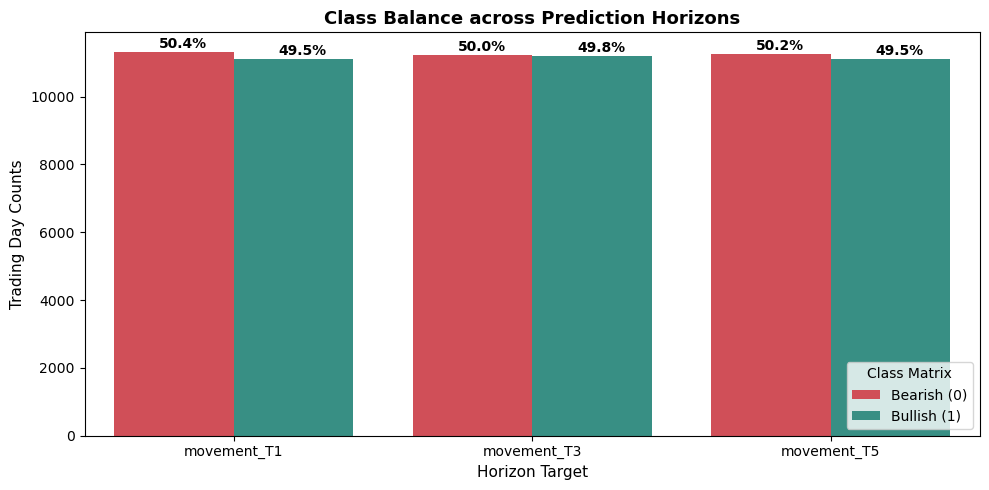

In [24]:
#Binary target class balance visual
#Financial color palette mapping

target_data = df_price[['movement_T1', 'movement_T3', 'movement_T5']].melt(var_name='Horizon', value_name='Class')
financial_palette = {0.0: '#E63946', 1.0: '#2A9D8F'}
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=target_data,
    x='Horizon', 
    hue='Class', 
    palette=financial_palette
)

plt.title('Class Balance across Prediction Horizons', fontsize=13, fontweight='bold')
plt.xlabel('Horizon Target', fontsize=11)
plt.ylabel('Trading Day Counts', fontsize=11)

#Ensuring legend matches the explicit hue maps
plt.legend(title='Class Matrix', labels=['Bearish (0)', 'Bullish (1)'],loc='lower right')

total = len(df_price)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating empty bars
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = height + (total * 0.005)
        ax.annotate(percentage, (x, y), fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.savefig('price_target_class_distributions.png', dpi=300)
plt.show()

In [25]:
#Saving Data
output_path3 = r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Price\price_features.csv"
df_price.to_csv(output_path3, index=False)
print('Success!')

Success!


In [30]:
df_price.describe()

,date,Adj_Close,Log_Return,Market_Return,excess_return,Excess_Return_Winsor,Target_T1,Target_T3,Target_T5,movement_T1,movement_T3,movement_T5,lag_return_1d_winsor,volatility_5d_winsor
count,22467,22467.000000,22467.000000,22467.000000,22467.000000,22467.000000,22452.000000,22422.000000,22392.000000,22452.000000,22422.000000,22392.000000,22467.000000,22467.000000
mean,2022-01-04 06:51:09.782347,83.915155,0.000371,0.000562,-0.000192,-0.000088,-0.000192,-0.000576,-0.000962,0.495368,0.499242,0.496740,-0.000084,0.015230
min,2019-01-10 00:00:00,3.438962,-0.773592,-0.127652,-0.694582,-0.056521,-0.694582,-0.839022,-0.981239,0.000000,0.000000,0.000000,-0.056521,0.000439
25%,2020-07-10 00:00:00,30.983728,-0.010525,-0.004606,-0.009015,-0.009015,-0.009023,-0.016586,-0.021817,0.000000,0.000000,0.000000,-0.009018,0.008750
50%,2022-01-04 00:00:00,46.666088,0.000836,0.000916,-0.000167,-0.000167,-0.000167,-0.000044,-0.000201,0.000000,0.000000,0.000000,-0.000165,0.013164
75%,2023-07-03 00:00:00,103.939960,0.011975,0.006909,0.008867,0.008867,0.008872,0.016225,0.021107,1.000000,1.000000,1.000000,0.008879,0.019940
max,2024-12-26 00:00:00,590.351685,0.258251,0.089683,0.240201,0.055177,0.240201,0.395778,0.527058,1.000000,1.000000,1.000000,0.055177,0.061179
std,NaN,85.651999,0.025324,0.012718,0.020735,0.017521,0.020741,0.036776,0.047290,0.499990,0.500011,0.500001,0.017529,0.008759
